In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pickle

In [67]:
# Read dictionnaries
with open("dictionnary_STUCON-tests.pkl", "rb") as f:
    dict_STUCON = pickle.load(f)
with open("dictionnary_LCP-tests.pkl", "rb") as f:
    dict_LCP = pickle.load(f)
with open("dictionnary_MLANG-tests.pkl", "rb") as f:
    dict_MLANG = pickle.load(f)

all_dicts = {
    "STUCON": dict_STUCON,
    "LCP": dict_LCP,
    "MLANG": dict_MLANG,
}

In [68]:
# Remove repetitions of the same configuration (only for STUCON)
repetition_list = ["_1_", "_2_", "_3_", "_4_"]

for var, d in all_dicts.items():
    rows = []

    for configuration, info in d.items():
        # Ignore if already existent
        if configuration == "kripp_df":
            continue

        if any(x in configuration for x in repetition_list):
            continue
        
        # Clean the names of the configurations
        configuration = configuration.replace("_0_", "_")
        
        results = info["kripp_results"]
        res_key = next(iter(results)) # take first result key: "streamlit_analysis_iteration_1"
        agg = results[res_key]["aggregated_metrics"]
        boot_diff = results[res_key]['run_results'][0]['bootstrap_differences']
        variance = np.var(boot_diff, ddof=1)
        n_bts = len(boot_diff)

        rows.append({
            "Configuration": configuration,
            "Human alpha": agg["alpha_human_panel_mean"],
            "Model alpha": agg["alpha_llm_substitution_panel_mean"],
            "Difference": agg["difference_mean"],
            "Variance": variance,
            "Weight": 1 / variance,
            "CI lower": agg["ci_lower_mean"],
            "CI upper": agg["ci_upper_mean"],
            "Non-inferior runs": agg["n_non_inferior"],
            "Boots nb" : n_bts
        })

    all_dicts[var]["kripp_df"] = pd.DataFrame(rows)

# Remove "no-thinkng" 2.5-pro from STUCON
to_remove = ['reasoning_codebook_examples-with-reasoning_2.5-pro', 
            'reasoning_codebook_examples-with-no-reasoning_2.5-pro',
            'codebook_examples-with-no-reasoning_2.5-pro',
            'codebook_2.5-pro',
            'simplified_2.5-pro',
            'simplest_2.5-pro',
            'no-scale_2.5-pro'
            ]

# Remove lines containing any of the strings in to_remove
all_dicts["STUCON"]["kripp_df"] = all_dicts["STUCON"]["kripp_df"][~all_dicts["STUCON"]["kripp_df"]["Configuration"].isin(to_remove)]

all_dicts["STUCON"]["kripp_df"]

,Configuration,Human alpha,Model alpha,Difference,Variance,Weight,CI lower,CI upper,Non-inferior runs,Boots nb
0,codebook_examples-with-no-reasoning_2.5-flash-...,0.803911,0.215448,-0.588463,0.000632,1583.115011,-0.628553,-0.547739,0,1000
1,simplified_2.5-flash-lite,0.803911,0.254548,-0.549363,0.000581,1720.873599,-0.591520,-0.511325,0,1000
2,reasoning_codebook_examples-with-reasoning_2.5...,0.803911,0.540469,-0.263442,0.000464,2156.603327,-0.301118,-0.230823,0,1000
3,simplest_2.5-flash-lite,0.803911,0.482155,-0.321756,0.000490,2042.193387,-0.358402,-0.284863,0,1000
4,no-scale_2.5-flash-lite,0.803911,0.549851,-0.254060,0.000442,2260.978581,-0.289663,-0.220452,0,1000
5,reasoning_codebook_examples-with-no-reasoning_...,0.803911,0.148317,-0.655594,0.000602,1661.161650,-0.695808,-0.616558,0,1000
6,codebook_2.5-flash-lite,0.803911,0.210961,-0.592950,0.000608,1645.078594,-0.634102,-0.554326,0,1000
7,thinking_no-scale_2.5-flash-lite,0.803911,0.580212,-0.223699,0.000436,2292.721762,-0.259269,-0.189214,0,1000
8,thinking_codebook_2.5-flash-lite,0.803911,0.433477,-0.370434,0.000549,1822.507855,-0.409323,-0.331738,0,1000
9,thinking_simplest_2.5-flash-lite,0.803911,0.564614,-0.239297,0.000457,2186.942300,-0.274652,-0.204905,0,1000


In [69]:
order = ["2.5-flash-lite", "2.5-flash", "2.5-pro"]

def to_long(df: pd.DataFrame, variable_name: str) -> pd.DataFrame:
    out = df.loc[:, ["Configuration", "Difference", "Variance", "Weight", "CI lower", "CI upper"]].copy()

    # Split after the last '_' to ge the model
    base_model = out["Configuration"].astype(str).str.rsplit("_", n=1, expand=True)

    out["Configuration"] = base_model[0]
    out["Model"] = base_model[1]

    out["Variable"] = variable_name
    out = out.rename(columns={"Difference": "Difference"})
    return out[["Configuration", "Model", "Variable", "Difference", "Variance", "Weight", "CI lower", "CI upper"]]

In [70]:
model_pattern = r"(2\.5-flash-lite|2\.5-flash|2\.5-pro)"

rename_tokens = {
    "codebook": "cbk",
    "examples-with-reasoning": "ex-explain",
    "examples-with-no-reasoning": "ex-no-explain",
    "reasoning": "CoT",
    "thinking": "tkg",
    "with-": ""
}

config_order = {
    "tkg_cbk_ex-explain": 1,
    "CoT_cbk_ex-explain": 2,
    "tkg_cbk_ex-no-explain": 3,
    "CoT_cbk_ex-no-explain": 4,
    "cbk_ex-no-explain": 5,
    "tkg_cbk": 6,
    "cbk": 7,
    "tkg_simplified": 8,
    "simplified": 9,
    "tkg_simplest": 10,
    "simplest": 11,
    "tkg_no-scale": 12,
    "no-scale": 13,
}

final_df = (
    pd.concat(
        [to_long(d["kripp_df"], var) for var, d in all_dicts.items()],
        ignore_index=True
    )
    .assign(
        Configuration_clean=lambda df: (
            df["Configuration"]
            .str.replace(model_pattern, "", regex=True)
            .replace(rename_tokens, regex=True)
            .str.strip("_- ")
        ),
        n_config=lambda df: df["Configuration_clean"].map(config_order)
    )
)

final_df

,Configuration,Model,Variable,Difference,Variance,Weight,CI lower,CI upper,Configuration_clean,n_config
0,codebook_examples-with-no-reasoning,2.5-flash-lite,STUCON,-0.588463,0.000632,1583.115011,-0.628553,-0.547739,cbk_ex-no-explain,5
1,simplified,2.5-flash-lite,STUCON,-0.549363,0.000581,1720.873599,-0.591520,-0.511325,simplified,9
2,reasoning_codebook_examples-with-reasoning,2.5-flash-lite,STUCON,-0.263442,0.000464,2156.603327,-0.301118,-0.230823,CoT_cbk_ex-explain,2
3,simplest,2.5-flash-lite,STUCON,-0.321756,0.000490,2042.193387,-0.358402,-0.284863,simplest,11
4,no-scale,2.5-flash-lite,STUCON,-0.254060,0.000442,2260.978581,-0.289663,-0.220452,no-scale,13
...,...,...,...,...,...,...,...,...,...,...
91,thinking_codebook_examples-with-no-reasoning,2.5-pro,MLANG,-0.307718,0.001582,632.054750,-0.373273,-0.242035,tkg_cbk_ex-no-explain,3
92,thinking_codebook_examples-with-reasoning,2.5-pro,MLANG,-0.313466,0.001456,686.889416,-0.378663,-0.254444,tkg_cbk_ex-explain,1
93,thinking_simplest,2.5-pro,MLANG,-0.523349,0.001970,507.574144,-0.597106,-0.449827,tkg_simplest,10
94,thinking_simplified,2.5-pro,MLANG,-0.626093,0.001819,549.799138,-0.698944,-0.556578,tkg_simplified,8


# Evolution of the alpha mean difference by models per variable

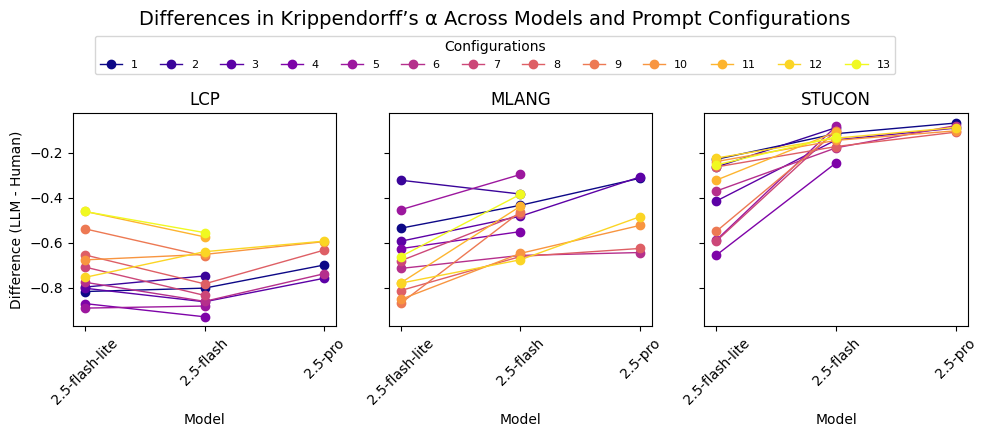

In [95]:
df = final_df.copy()
df["Model"] = pd.Categorical(df["Model"], categories=order, ordered=True)
df = df.sort_values(["Variable", "Configuration", "Model"])

df = (df.groupby(["Configuration", "n_config", "Variable", "Model"], observed=True, as_index=False)
        .agg(Difference=("Difference", "mean")))

x_map = {m: i for i, m in enumerate(order)}
variables = df["Variable"].unique()

handles = {}
fig, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
cmap = mpl.colormaps["plasma"].resampled(13)
colors = {i + 1: cmap(i) for i in range(13)}
for ax, var in zip(axes, variables):
    sub = df[df["Variable"] == var]
    
    for cfg, g in sub.groupby("n_config"):
        xs = [x_map[m] for m in g["Model"]]
        ys = g["Difference"].to_numpy()

        line, = ax.plot(
            xs,
            ys,
            marker="o",
            linewidth=1,
            color=colors[cfg],
            label=cfg
        )
        if cfg not in handles:
            handles[cfg] = line

    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(order, rotation=45)
    ax.set_title(var)
    ax.set_xlabel("Model")

axes[0].set_ylabel("Difference (LLM - Human)")

fig.suptitle(
    "Differences in Krippendorff’s α Across Models and Prompt Configurations",
    fontsize=14,
    y=1.08
)

fig.legend(
    handles.values(),
    handles.keys(),
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    ncol=13,
    fontsize=8,
    title="Configurations"
)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

# Mean by model (only on thinking configurations)

In [72]:
mean_by_model = (
    final_df[final_df["Configuration"].str.startswith("thinking")]
    .groupby("Model")["Difference"]
    .agg(["mean", "std", "count"])
    .rename(columns={
        "mean": "Raw_Mean_Difference",
        "std": "SD",
        "count": "N"
    })
    .reindex(order)
    .reset_index()
)

mean_by_model["SE"] = mean_by_model["SD"] / np.sqrt(mean_by_model["N"])
mean_by_model

,Model,Raw_Mean_Difference,SD,N,SE
0,2.5-flash-lite,-0.584349,0.232345,18,0.054764
1,2.5-flash,-0.503015,0.279974,18,0.065991
2,2.5-pro,-0.414144,0.264487,18,0.062340


For each model $M$, the inverse-variance weighted mean is defined as:

$$
\bar{m}_M =
\frac{\sum_i \dfrac{m_i}{\hat{\sigma}_i^2}}
{\sum_i \dfrac{1}{\hat{\sigma}_i^2}}
$$

where:
- $m_i$ is the mean of bootstrap replicates for a given (variable $\times$ prompt) combination,
-  $\hat{\sigma}_i^2$ is the bootstrap variance associated with $m_i$.

In [73]:
def weighted_stats(g):
    w = g["Weight"]
    x = g["Difference"]
    
    wm = np.average(x, weights=w)
    se = np.sqrt(1 / np.sum(w))

    return pd.Series({
        "Weighted_Mean_Difference": wm,
        "Weighted_SE": se,
        "N": x.count()
    })

weighted_by_model = (
    final_df[final_df["Configuration"].str.startswith("thinking")]
    .groupby("Model")
    .apply(weighted_stats, include_groups=False)
    .reindex(order)
    .reset_index()
)
weighted_by_model

,Model,Weighted_Mean_Difference,Weighted_SE,N
0,2.5-flash-lite,-0.425064,0.007379,18.0
1,2.5-flash,-0.268485,0.006514,18.0
2,2.5-pro,-0.176130,0.005770,18.0


In [74]:
summary_by_model = mean_by_model.merge(
    weighted_by_model,
    on="Model",
    how="left"
)

summary_by_model["Model"] = pd.Categorical(summary_by_model["Model"], categories=order, ordered=True)
summary_by_model = summary_by_model.sort_values("Model")

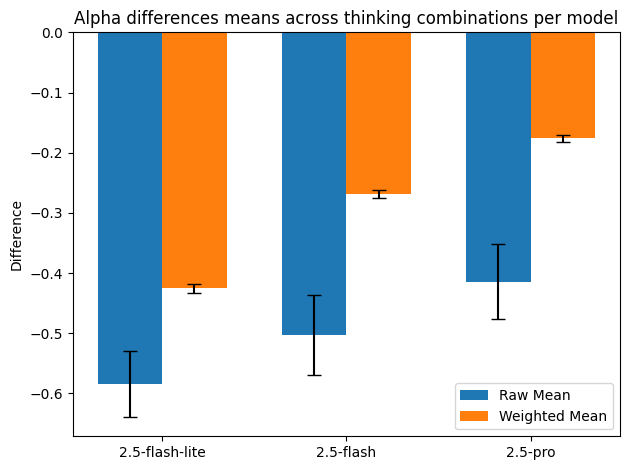

In [75]:
x = np.arange(len(summary_by_model))
width = 0.35

plt.figure()

# Raw mean
plt.bar(
    x - width/2,
    summary_by_model["Raw_Mean_Difference"],
    width,
    yerr=summary_by_model["SE"],
    capsize=5,
    label="Raw Mean"
)

# Weighted mean
plt.bar(
    x + width/2,
    summary_by_model["Weighted_Mean_Difference"],
    width,
    yerr=summary_by_model["Weighted_SE"],
    capsize=5,
    label="Weighted Mean"
)

plt.xticks(x, summary_by_model["Model"])
plt.ylabel("Difference")
plt.legend()
plt.title("Alpha differences means across thinking combinations per model")
plt.tight_layout()
plt.show()

In [76]:
summary_by_model.drop(columns=["N_x"])

,Model,Raw_Mean_Difference,SD,SE,Weighted_Mean_Difference,Weighted_SE,N_y
0,2.5-flash-lite,-0.584349,0.232345,0.054764,-0.425064,0.007379,18.0
1,2.5-flash,-0.503015,0.279974,0.065991,-0.268485,0.006514,18.0
2,2.5-pro,-0.414144,0.264487,0.062340,-0.176130,0.005770,18.0


# Mean by configuration

In [77]:
mean_by_cfg = (
    final_df[~final_df["Model"].str.startswith("2.5-pro")]
    .groupby(["Configuration", "Configuration_clean", "n_config"])["Difference"]
    .agg(["mean", "std", "count"])
    .rename(columns={
        "mean": "Raw_Mean_Difference",
        "std": "SD",
        "count": "N"
    })
    .reset_index()
)
mean_by_cfg["SE"] = (
    mean_by_cfg["SD"] / np.sqrt(mean_by_cfg["N"])
)
mean_by_cfg

,Configuration,Configuration_clean,n_config,Raw_Mean_Difference,SD,N,SE
0,codebook,cbk,7,-0.565358,0.257376,6,0.105073
1,codebook_examples-with-no-reasoning,cbk_ex-no-explain,5,-0.532614,0.322266,6,0.131565
2,no-scale,no-scale,13,-0.408031,0.195626,6,0.079864
3,reasoning_codebook_examples-with-no-reasoning,CoT_cbk_ex-no-explain,4,-0.646751,0.245823,6,0.100357
4,reasoning_codebook_examples-with-reasoning,CoT_cbk_ex-explain,2,-0.434083,0.281135,6,0.114773
5,simplest,simplest,11,-0.447138,0.227221,6,0.092763
6,simplified,simplified,9,-0.531077,0.252384,6,0.103035
7,thinking_codebook,tkg_cbk,6,-0.593175,0.263290,6,0.107488
8,thinking_codebook_examples-with-no-reasoning,tkg_cbk_ex-no-explain,3,-0.550225,0.265705,6,0.108473
9,thinking_codebook_examples-with-reasoning,tkg_cbk_ex-explain,1,-0.489213,0.289501,6,0.118188


In [78]:
weighted_by_cfg = (
    final_df[~final_df["Model"].str.startswith("2.5-pro")]
    .groupby(["Configuration", "Configuration_clean", "n_config"])
    .apply(weighted_stats, include_groups=False)
    .reset_index()
)
weighted_by_cfg

,Configuration,Configuration_clean,n_config,Weighted_Mean_Difference,Weighted_SE,N
0,codebook,cbk,7,-0.351619,0.011704,6.0
1,codebook_examples-with-no-reasoning,cbk_ex-no-explain,5,-0.323431,0.011614,6.0
2,no-scale,no-scale,13,-0.274373,0.011823,6.0
3,reasoning_codebook_examples-with-no-reasoning,CoT_cbk_ex-no-explain,4,-0.516381,0.013199,6.0
4,reasoning_codebook_examples-with-reasoning,CoT_cbk_ex-explain,2,-0.238980,0.011183,6.0
5,simplest,simplest,11,-0.292150,0.011749,6.0
6,simplified,simplified,9,-0.353702,0.011631,6.0
7,thinking_codebook,tkg_cbk,6,-0.405226,0.012603,6.0
8,thinking_codebook_examples-with-no-reasoning,tkg_cbk_ex-no-explain,3,-0.355431,0.012247,6.0
9,thinking_codebook_examples-with-reasoning,tkg_cbk_ex-explain,1,-0.272275,0.011484,6.0


In [79]:
summary_by_cfg = mean_by_cfg.merge(
    weighted_by_cfg,
    on=["Configuration", "Configuration_clean", "n_config", "N"],
    how="left"
)

summary_by_cfg["Configuration"] = pd.Categorical(summary_by_cfg["Configuration"])
summary_by_cfg = summary_by_cfg.sort_values("Weighted_Mean_Difference").reset_index(drop=True)
summary_by_cfg

,Configuration,Configuration_clean,n_config,Raw_Mean_Difference,SD,N,SE,Weighted_Mean_Difference,Weighted_SE
0,reasoning_codebook_examples-with-no-reasoning,CoT_cbk_ex-no-explain,4,-0.646751,0.245823,6,0.100357,-0.516381,0.013199
1,thinking_codebook,tkg_cbk,6,-0.593175,0.263290,6,0.107488,-0.405226,0.012603
2,thinking_simplified,tkg_simplified,8,-0.558396,0.272775,6,0.111360,-0.359961,0.012095
3,thinking_codebook_examples-with-no-reasoning,tkg_cbk_ex-no-explain,3,-0.550225,0.265705,6,0.108473,-0.355431,0.012247
4,simplified,simplified,9,-0.531077,0.252384,6,0.103035,-0.353702,0.011631
5,codebook,cbk,7,-0.565358,0.257376,6,0.105073,-0.351619,0.011704
6,thinking_simplest,tkg_simplest,10,-0.535847,0.278413,6,0.113661,-0.329298,0.011735
7,codebook_examples-with-no-reasoning,cbk_ex-no-explain,5,-0.532614,0.322266,6,0.131565,-0.323431,0.011614
8,thinking_no-scale,tkg_no-scale,12,-0.535237,0.281680,6,0.114995,-0.315023,0.011713
9,simplest,simplest,11,-0.447138,0.227221,6,0.092763,-0.292150,0.011749


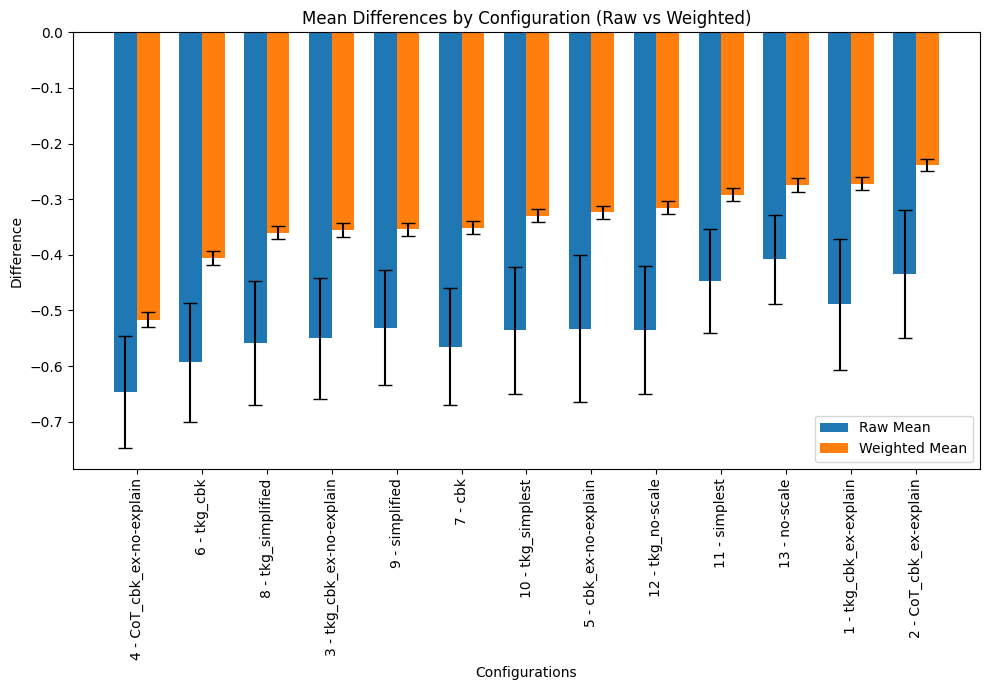

In [96]:
x = np.arange(len(summary_by_cfg))
width = 0.35

plt.figure(figsize=(10, 7))

# Raw mean
plt.bar(
    x - width/2,
    summary_by_cfg["Raw_Mean_Difference"],
    width,
    yerr=summary_by_cfg["SE"],
    capsize=5,
    label="Raw Mean"
)

# Weighted mean
plt.bar(
    x + width/2,
    summary_by_cfg["Weighted_Mean_Difference"],
    width,
    yerr=summary_by_cfg["Weighted_SE"],
    capsize=5,
    label="Weighted Mean"
)
x_labels = summary_by_cfg["n_config"].astype(str) + " - " + summary_by_cfg["Configuration_clean"]
plt.xticks(x, x_labels, rotation=90)
plt.ylabel("Difference")
plt.xlabel("Configurations")
plt.title("Mean Differences by Configuration (Raw vs Weighted)")
plt.legend()
plt.tight_layout()
plt.show()

# Mean by dimensions

In [81]:
mean_by_var = (
    final_df
    .groupby("Variable")["Difference"]
    .agg(["mean", "std", "count"])
    .rename(columns={
        "mean": "Raw_Mean_Difference",
        "std": "SD",
        "count": "N"
    })
    .reset_index()
)
mean_by_var["SE"] = (
    mean_by_var["SD"] / np.sqrt(mean_by_var["N"])
)
mean_by_var

,Variable,Raw_Mean_Difference,SD,N,SE
0,LCP,-0.719603,0.126049,32,0.022282
1,MLANG,-0.566917,0.164008,32,0.028993
2,STUCON,-0.226526,0.167593,32,0.029627


In [82]:
weighted_by_var = (
    final_df
    .groupby("Variable")
    .apply(weighted_stats, include_groups=False)
    .reset_index()
)
weighted_by_var

,Variable,Weighted_Mean_Difference,Weighted_SE,N
0,LCP,-0.719562,0.009009,32.0
1,MLANG,-0.567134,0.007414,32.0
2,STUCON,-0.182922,0.003302,32.0


In [83]:
summary_by_var = mean_by_var.merge(
    weighted_by_var,
    on="Variable",
    how="left"
)

summary_by_var["Configuration"] = pd.Categorical(summary_by_var["Variable"])
summary_by_var = summary_by_var.sort_values("Weighted_Mean_Difference").reset_index(drop=True)
summary_by_var

,Variable,Raw_Mean_Difference,SD,N_x,SE,Weighted_Mean_Difference,Weighted_SE,N_y,Configuration
0,LCP,-0.719603,0.126049,32,0.022282,-0.719562,0.009009,32.0,LCP
1,MLANG,-0.566917,0.164008,32,0.028993,-0.567134,0.007414,32.0,MLANG
2,STUCON,-0.226526,0.167593,32,0.029627,-0.182922,0.003302,32.0,STUCON


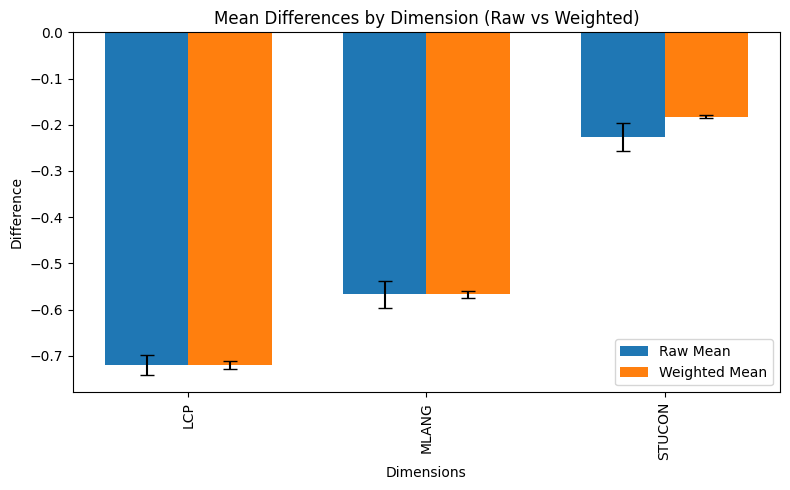

In [107]:
x = np.arange(len(summary_by_var))
width = 0.35

plt.figure(figsize=(8, 5))

# Raw mean
plt.bar(
    x - width/2,
    summary_by_var["Raw_Mean_Difference"],
    width,
    yerr=summary_by_var["SE"],
    capsize=5,
    label="Raw Mean"
)

# Weighted mean
plt.bar(
    x + width/2,
    summary_by_var["Weighted_Mean_Difference"],
    width,
    yerr=summary_by_var["Weighted_SE"],
    capsize=5,
    label="Weighted Mean"
)

plt.xticks(x, summary_by_var["Variable"], rotation=90)
plt.ylabel("Difference")
plt.xlabel("Dimensions")
plt.title("Mean Differences by Dimension (Raw vs Weighted)")
plt.legend()
plt.tight_layout()
plt.show()

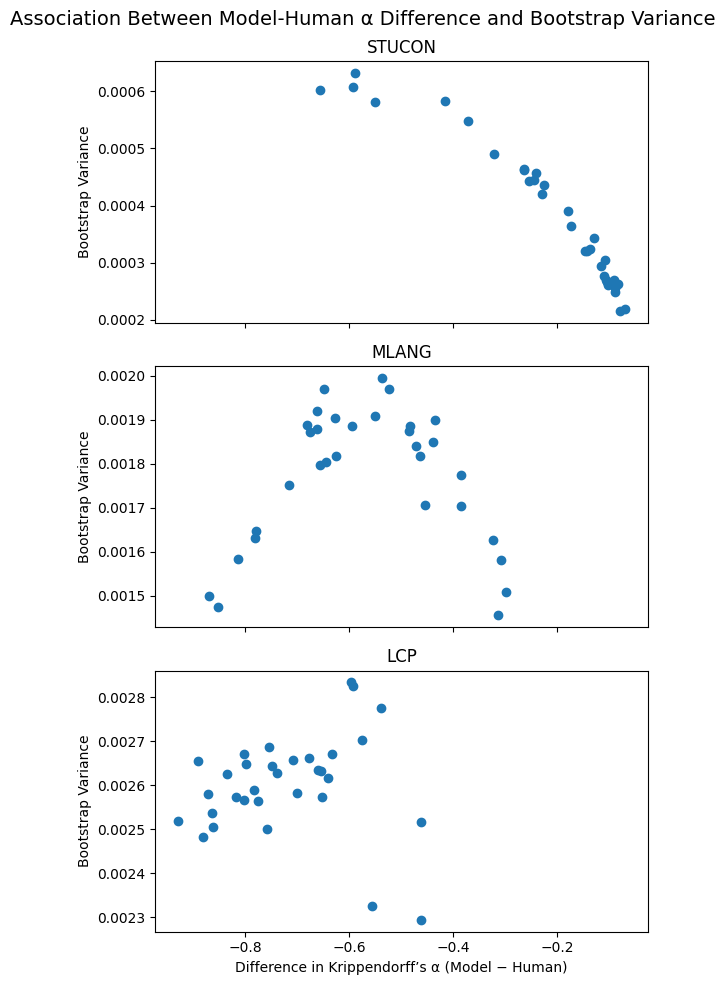

In [85]:
variables = ["STUCON", "MLANG", "LCP"]

fig, axes = plt.subplots(3, 1, figsize=(6, 10), sharex=True)

for ax, var in zip(axes, variables):
    sub = final_df[final_df["Variable"] == var]
    
    x = sub["Difference"]
    y = sub["Variance"]
    
    ax.scatter(x, y)
    ax.set_title(var)
    ax.set_ylabel("Bootstrap Variance")

axes[2].set_xlabel("Difference in Krippendorff’s α (Model − Human)")

fig.suptitle(
    "Association Between Model-Human α Difference and Bootstrap Variance",
    fontsize=14,
    y=0.98
)

plt.tight_layout()
plt.show()

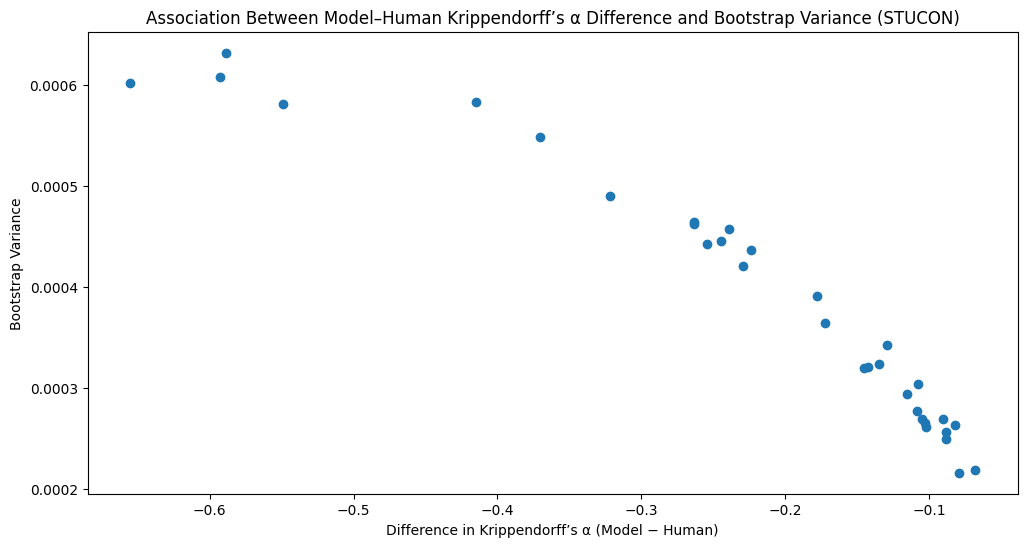

In [86]:
plt.figure(figsize=(12, 6))

y = final_df[final_df["Variable"] == "STUCON"]["Variance"]
x = final_df[final_df["Variable"] == "STUCON"]["Difference"]

plt.scatter(x, y)

plt.title("Association Between Model–Human Krippendorff’s α Difference and Bootstrap Variance (STUCON)")
plt.xlabel("Difference in Krippendorff’s α (Model − Human)")
plt.ylabel("Bootstrap Variance")

plt.show()

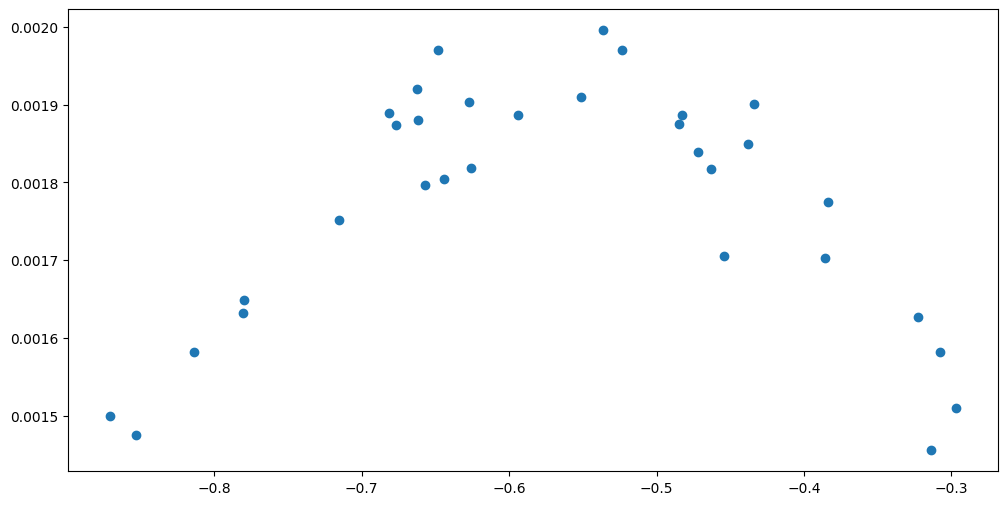

In [87]:
plt.figure(figsize=(12, 6))
y = final_df[final_df["Variable"] == "MLANG"]["Variance"]
x = final_df[final_df["Variable"] == "MLANG"]["Difference"]
plt.scatter(x, y)
plt.show()

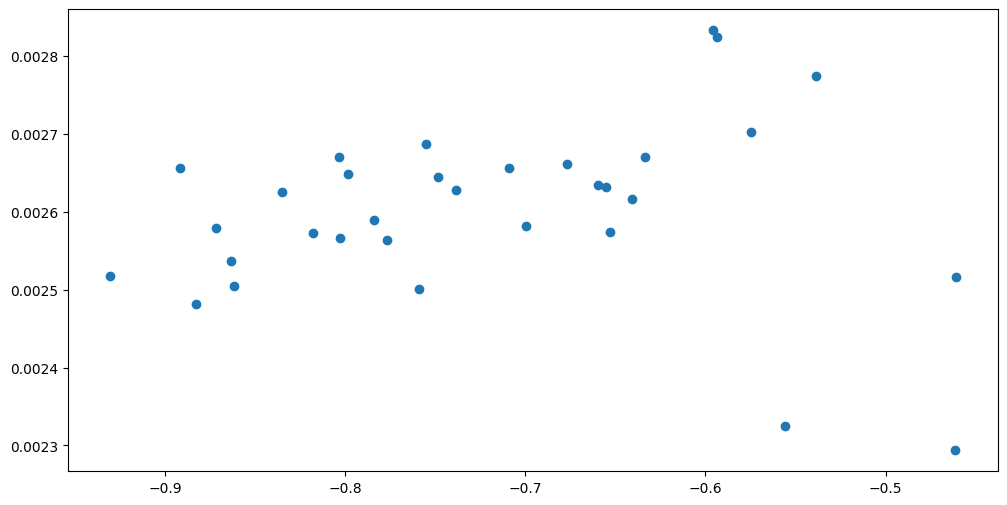

In [88]:
plt.figure(figsize=(12, 6))
y = final_df[final_df["Variable"] == "LCP"]["Variance"]
x = final_df[final_df["Variable"] == "LCP"]["Difference"]
plt.scatter(x, y)
plt.show()

# Choose the best / least worst configuration

In [100]:
def extended_weighted_stats(g):
    w = g["Weight"]
    x = g["Difference"]
    ci_low = g["CI lower"]
    
    wm = np.average(x, weights=w)
    se = np.sqrt(1 / np.sum(w))
    ci_low_wm = np.average(ci_low, weights=w)

    return pd.Series({
        "Weighted_Mean_Difference": wm,
        "Weighted_SE": se,
        "Weighted_lower_CI": ci_low_wm,
    })

mean_by_cfg_model = (
    final_df
    .groupby(["Configuration", "Configuration_clean", "n_config", "Model"], as_index=False)
    .apply(extended_weighted_stats, include_groups=False)
    .sort_values("Weighted_lower_CI", ascending=False)
)

mean_by_cfg_model

,Configuration,Configuration_clean,n_config,Model,Weighted_Mean_Difference,Weighted_SE,Weighted_lower_CI
22,thinking_codebook_examples-with-reasoning,tkg_cbk_ex-explain,1,2.5-pro,-0.140946,0.013298,-0.175071
25,thinking_no-scale,tkg_no-scale,12,2.5-pro,-0.167592,0.014285,-0.203775
8,reasoning_codebook_examples-with-reasoning,CoT_cbk_ex-explain,2,2.5-flash,-0.173976,0.014362,-0.211454
16,thinking_codebook,tkg_cbk,6,2.5-pro,-0.180308,0.013403,-0.212969
19,thinking_codebook_examples-with-no-reasoning,tkg_cbk_ex-no-explain,3,2.5-pro,-0.175499,0.014516,-0.214215
2,codebook_examples-with-no-reasoning,cbk_ex-no-explain,5,2.5-flash,-0.177547,0.014333,-0.214327
28,thinking_simplest,tkg_simplest,10,2.5-pro,-0.186208,0.014696,-0.222960
12,simplified,simplified,9,2.5-flash,-0.192640,0.014674,-0.230997
10,simplest,simplest,11,2.5-flash,-0.191294,0.015434,-0.231720
0,codebook,cbk,7,2.5-flash,-0.202974,0.014510,-0.239839


In [99]:
mean_by_cfg_model.sort_values("Weighted_Mean_Difference", ascending=False).head(5)

,Configuration,Configuration_clean,n_config,Model,Weighted_Mean_Difference,Weighted_SE,Weighted_lower_CI
22,thinking_codebook_examples-with-reasoning,tkg_cbk_ex-explain,1,2.5-pro,-0.140946,0.013298,-0.175071
25,thinking_no-scale,tkg_no-scale,12,2.5-pro,-0.167592,0.014285,-0.203775
8,reasoning_codebook_examples-with-reasoning,CoT_cbk_ex-explain,2,2.5-flash,-0.173976,0.014362,-0.211454
19,thinking_codebook_examples-with-no-reasoning,tkg_cbk_ex-no-explain,3,2.5-pro,-0.175499,0.014516,-0.214215
2,codebook_examples-with-no-reasoning,cbk_ex-no-explain,5,2.5-flash,-0.177547,0.014333,-0.214327


In [91]:
mean_by_cfg_model.sort_values("Weighted_lower_CI", ascending=False).head(10)

,Configuration,Configuration_clean,n_config,Model,Weighted_Mean_Difference,Weighted_SE,Weighted_lower_CI
22,thinking_codebook_examples-with-reasoning,tkg_cbk_ex-explain,1,2.5-pro,-0.140946,0.013298,-0.175071
25,thinking_no-scale,tkg_no-scale,12,2.5-pro,-0.167592,0.014285,-0.203775
8,reasoning_codebook_examples-with-reasoning,CoT_cbk_ex-explain,2,2.5-flash,-0.173976,0.014362,-0.211454
16,thinking_codebook,tkg_cbk,6,2.5-pro,-0.180308,0.013403,-0.212969
19,thinking_codebook_examples-with-no-reasoning,tkg_cbk_ex-no-explain,3,2.5-pro,-0.175499,0.014516,-0.214215
2,codebook_examples-with-no-reasoning,cbk_ex-no-explain,5,2.5-flash,-0.177547,0.014333,-0.214327
28,thinking_simplest,tkg_simplest,10,2.5-pro,-0.186208,0.014696,-0.222960
12,simplified,simplified,9,2.5-flash,-0.192640,0.014674,-0.230997
10,simplest,simplest,11,2.5-flash,-0.191294,0.015434,-0.231720
0,codebook,cbk,7,2.5-flash,-0.202974,0.014510,-0.239839


In [104]:
desired_order = [
    "tkg_cbk_ex-explain",
    "CoT_cbk_ex-explain",
    "tkg_cbk_ex-no-explain",
    "CoT_cbk_ex-no-explain",
    "cbk_ex-no-explain",
    "tkg_cbk",
    "cbk",
    "tkg_simplified",
    "simplified",
    "tkg_simplest",
    "simplest",
    "tkg_no-scale",
    "no-scale", 
]

mat = mean_by_cfg_model.pivot_table(
    index="Model",
    columns="Configuration_clean",
    values="Weighted_Mean_Difference",
    aggfunc="mean"
)
mat = mat.reindex(order)
mat = mat.reindex(columns=[c for c in desired_order if c in mat.columns])
mat.T

Model,2.5-flash-lite,2.5-flash,2.5-pro
Configuration_clean,,,
tkg_cbk_ex-explain,-0.346314,-0.216197,-0.140946
CoT_cbk_ex-explain,-0.339071,-0.173976,NaN
tkg_cbk_ex-no-explain,-0.506597,-0.257511,-0.175499
CoT_cbk_ex-no-explain,-0.682285,-0.381482,NaN
cbk_ex-no-explain,-0.602345,-0.177547,NaN
tkg_cbk,-0.498039,-0.331685,-0.180308
cbk,-0.628391,-0.202974,NaN
tkg_simplified,-0.419742,-0.308126,-0.214478
simplified,-0.625883,-0.192640,NaN


In [105]:
mat.columns = [f"{config_order.get(cfg, '?')}. {cfg}" for cfg in mat.columns]
mat.T

Model,2.5-flash-lite,2.5-flash,2.5-pro
1. tkg_cbk_ex-explain,-0.346314,-0.216197,-0.140946
2. CoT_cbk_ex-explain,-0.339071,-0.173976,NaN
3. tkg_cbk_ex-no-explain,-0.506597,-0.257511,-0.175499
4. CoT_cbk_ex-no-explain,-0.682285,-0.381482,NaN
5. cbk_ex-no-explain,-0.602345,-0.177547,NaN
6. tkg_cbk,-0.498039,-0.331685,-0.180308
7. cbk,-0.628391,-0.202974,NaN
8. tkg_simplified,-0.419742,-0.308126,-0.214478
9. simplified,-0.625883,-0.192640,NaN
10. tkg_simplest,-0.418425,-0.257482,-0.186208


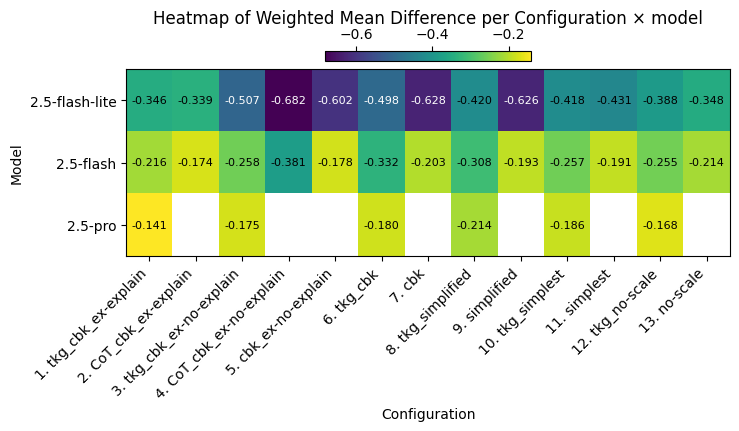

In [106]:
fig, ax = plt.subplots(figsize=(2.5*mat.shape[0], 0.35*mat.shape[1]))

im = ax.imshow(mat.to_numpy(), aspect="auto")

ax.set_xticks(np.arange(mat.shape[1]))
ax.set_xticklabels(mat.columns.astype(str), rotation=45, ha="right")
ax.set_yticks(np.arange(mat.shape[0]))
ax.set_yticklabels(mat.index.astype(str))

ax.set_xlabel("Configuration")
ax.set_ylabel("Model")
ax.set_title("Heatmap of Weighted Mean Difference per Configuration × model", y=1.2)

cbar = fig.colorbar(
    im,
    ax=ax,
    orientation="horizontal",
    location="top",
    pad=0.04,
    fraction=0.05
)
# cbar.set_label("Weighted Mean Difference", fontsize=10)

for i in range(mat.shape[0]):
    for j in range(mat.shape[1]):
        val = mat.iat[i, j]
        if pd.notna(val):
            threshold = (np.nanmax(mat.values) + np.nanmin(mat.values)) / 1.7

            color = "white" if val < threshold else "black"

            ax.text(j, i, f"{val:.3f}", ha="center", va="center",
                    fontsize=8, color=color)

plt.tight_layout()
plt.show()

While 2.5-pro achieved the best performance, its cost makes it impractical for large-scale deployment. Therefore, selection was restricted to the third best configuration: reasoning_codebook_examples-with-reasoning from the 2.5-flash-lite model.